**Non-deep learning Feature Extraction**

This script is designed for feature extraction, analysis, and visualization of in-distribution and out-distribution datasets in a machine learning pipeline. It performs the following key steps:


*   Feature Extraction: Computes diverse feature types (e.g., intensity, texture, topological, and morphological features) from medical images and saves the results as CSV files for both in-distribution and out-distribution datasets.
*   Feature Loading: Reads the extracted features from the CSV files and prepares them for further analysis.
*   Feature Visualization: Implements various techniques, including t-SNE, PCA, UMAP, boxplots, and KDE, to explore and compare the distributions of the extracted features, enabling insights into dataset similarities and differences.

**You need the following libraries to run the code:**

*   SimpleITK==2.2.1
*   pyradiomics==3.0.1
*   seaborn==0.12.2
*   umap-learn==0.5.4
*   scikit-image==0.21.0
*   gudhi==3.8.0
*   numpy==1.24.4
*   scipy==1.11.3
*   pandas==2.1.2
*   matplotlib==3.8.2
*   scikit-learn==1.4.0List item


In [3]:
# Import necessary libraries
import os
import numpy as np
import SimpleITK as sitk
from scipy.stats import skew, kurtosis
from scipy.ndimage import gaussian_laplace
from skimage.filters import laplace
from skimage.measure import (
    moments_central, moments_hu, label, euler_number, regionprops, shannon_entropy
)
from skimage.feature import local_binary_pattern
import pandas as pd
from gudhi import CubicalComplex
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from umap import UMAP


In [4]:
# Define the available feature categories and their corresponding methods
FEATURE_FUNCTIONS = {
    "intensity": ["mean", "variance", "skewness", "kurtosis"],
    "gradient": ["gradient_magnitude"],
    "frequency": ["fourier_energy", "frequency_entropy"],
    "edges": ["edge_density", "edge_mean_intensity"],
    "topology": ["euler_number", "entropy", "betti_0", "betti_1"],
    "moments": ["hu_moments"],
    "morphological": ["area", "perimeter", "eccentricity", "aspect_ratio"],
    "log": ["laplacian_variance"],
    "texture": ["lbp_histogram"],
}


In [5]:
# --------- Feature Computation Functions --------- #

def compute_intensity_features(image):
    """
    Compute basic intensity features of an image.
    Features include:
        - Mean intensity
        - Variance of intensity
        - Skewness (asymmetry of intensity distribution)
        - Kurtosis (peakedness of intensity distribution)
    """
    flat_image = image.flatten()
    return {
        "mean": np.mean(flat_image),
        "variance": np.var(flat_image),
        "skewness": skew(flat_image),
        "kurtosis": kurtosis(flat_image),
    }

def compute_gradient_features(image):
    """
    Compute gradient-based features of an image.
    Features include:
        - Average gradient magnitude (measures edge strength)
    """
    gradient = np.gradient(image.astype(float))
    magnitude = np.sqrt(gradient[0]**2 + gradient[1]**2)
    return {"gradient_magnitude": np.mean(magnitude)}

def compute_frequency_features(image):
    """
    Compute frequency-domain features using Fourier Transform.
    Features include:
        - Fourier energy (sum of power spectrum)
        - Frequency entropy (measures complexity of frequency distribution)
    """
    fft = np.fft.fft2(image)
    power_spectrum = np.abs(fft)**2
    frequency_entropy = -np.sum(power_spectrum * np.log2(power_spectrum + 1e-10))
    return {
        "fourier_energy": np.sum(power_spectrum),
        "frequency_entropy": frequency_entropy,
    }

def compute_edge_features(image):
    """
    Compute edge-based features using the Canny edge detector.
    Features include:
        - Edge density (fraction of edge pixels in the image)
        - Mean intensity of edge pixels
    """
    from skimage.feature import canny
    edges = canny(image, sigma=1.0)
    edge_density = np.sum(edges) / edges.size
    edge_mean_intensity = np.mean(image[edges]) if np.sum(edges) > 0 else 0
    return {"edge_density": edge_density, "edge_mean_intensity": edge_mean_intensity}

def compute_topological_features(image):
    """
    Compute topological features of an image.
    Features include:
        - Euler number (number of connected components minus holes)
        - Shannon entropy (measures texture complexity)
        - Betti numbers (H_0: connected components, H_1: loops)
    """
    threshold = image > np.percentile(image, 50)
    betti_features = compute_betti_numbers(image)
    return {
        "euler_number": euler_number(threshold),
        "entropy": shannon_entropy(image),
        **betti_features,
    }

def compute_betti_numbers(image):
    """
    Compute Betti numbers using a cubical complex.
    Features include:
        - Betti-0 (connected components)
        - Betti-1 (loops or holes)
    """
    cubical_complex = CubicalComplex(top_dimensional_cells=image.astype(float))
    persistence = cubical_complex.persistence()

    # Extract Betti numbers
    betti_0 = sum(1 for interval in persistence if interval[0] == 0)  # H_0
    betti_1 = sum(1 for interval in persistence if interval[0] == 1)  # H_1
    return {"betti_0": betti_0, "betti_1": betti_1}

def compute_moment_features(image):
    """
    Compute Hu moments for shape and texture representation.
    Features include:
        - Seven invariant Hu moments for rotation, scale, and translation
    """
    moments_hu_vals = moments_hu(moments_central(image))
    return {f"hu_moment_{i+1}": moments_hu_vals[i] for i in range(len(moments_hu_vals))}

def compute_morphological_features(image):
    """
    Compute morphological features such as area and shape metrics.
    Features include:
        - Area (number of pixels in thresholded region)
        - Perimeter (length of boundary)
        - Eccentricity (shape elongation)
        - Aspect ratio (ratio of major to minor axis lengths)
    """
    threshold = image > np.percentile(image, 50)
    props = regionprops(label(threshold))
    if not props:
        return {"area": 0, "perimeter": 0, "eccentricity": 0, "aspect_ratio": 0}
    prop = props[0]
    area = prop.area
    perimeter = prop.perimeter
    eccentricity = prop.eccentricity
    aspect_ratio = prop.major_axis_length / prop.minor_axis_length if prop.minor_axis_length > 0 else 0
    return {"area": area, "perimeter": perimeter, "eccentricity": eccentricity, "aspect_ratio": aspect_ratio}

def compute_log_features(image):
    """
    Compute Laplacian of Gaussian (LoG)-based features.
    Features include:
        - Variance of Laplacian, a measure of texture and edges
    """
    laplacian = laplace(image.astype(float))
    return {"laplacian_variance": np.var(laplacian)}

def compute_texture_features(image):
    """
    Compute texture features using Local Binary Patterns (LBP).
    Features include:
        - LBP histogram bins normalized to sum to 1
    """
    lbp = local_binary_pattern(image, P=8, R=1, method="uniform")  # P=8 neighbors, R=radius
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 10), range=(0, 9))
    hist = hist / hist.sum()  # Normalize histogram
    return {f"lbp_bin_{i+1}": hist[i] for i in range(len(hist))}

# --------- Feature Extraction Pipeline --------- #

def extract_features(image, selected_features):
    """
    Extract selected features from the given image.

    Parameters:
        image (np.array): Input image.
        selected_features (list): List of feature types to compute.

    Returns:
        dict: Dictionary containing computed features.
    """
    features = {}
    if "intensity" in selected_features:
        features.update(compute_intensity_features(image))
    if "gradient" in selected_features:
        features.update(compute_gradient_features(image))
    if "frequency" in selected_features:
        features.update(compute_frequency_features(image))
    if "edges" in selected_features:
        features.update(compute_edge_features(image))
    if "topology" in selected_features:
        features.update(compute_topological_features(image))
    if "moments" in selected_features:
        features.update(compute_moment_features(image))
    if "morphological" in selected_features:
        features.update(compute_morphological_features(image))
    if "log" in selected_features:
        features.update(compute_log_features(image))
    if "texture" in selected_features:
        features.update(compute_texture_features(image))
    return features

def feature_extraction_pipeline(input_folder, output_csv, selected_features):
    """
    Extract features from all images in a folder and save to a CSV file.

    Parameters:
        input_folder (str): Path to the folder containing input images.
        output_csv (str): Path to save the output CSV file.
        selected_features (list): List of feature types to compute.

    Returns:
        None: Saves extracted features to a CSV file.
    """
    image_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(".png") or f.endswith(".jpg")]
    all_features = []

    for image_file in image_files:
        try:
            # Load image
            image = sitk.GetArrayFromImage(sitk.ReadImage(image_file))
            image = (image / np.max(image) * 255).astype(np.uint8)  # Normalize

            # Extract features
            features = extract_features(image, selected_features)
            features["Image"] = os.path.basename(image_file)
            all_features.append(features)

        except Exception as e:
            print(f"Error processing {image_file}: {e}")

    # Save to CSV
    df = pd.DataFrame(all_features)
    df.to_csv(output_csv, index=False)
    print(f"Features saved to {output_csv}")


In [15]:
if __name__ == "__main__":
    """
    Main entry point for the feature extraction script.
    This script allows the user to select feature categories, specify input directories
    for in-distribution and out-distribution images, and extract selected features
    to CSV files.
    """

    # Display available feature categories to the user
    print("Available Features:")
    for category, feature_list in FEATURE_FUNCTIONS.items():
        print(f"  {category}: {', '.join(feature_list)}")
    print("  all: Selects all available features.")  # Option to select all features

    # Prompt the user to select feature categories
    selected_categories = input(
        "Enter the feature categories to extract (comma-separated, or 'all' for all features): "
    ).split(",")
    if "all" in selected_categories:
        # If 'all' is selected, include all feature categories
        selected_features = list(FEATURE_FUNCTIONS.keys())
    else:
        # Filter selected categories based on user input
        selected_features = [
            category.strip()
            for category in selected_categories
            if category.strip() in FEATURE_FUNCTIONS
        ]

    # Prompt the user to specify the input and output paths
    in_dist_folder = input("Enter the path to the in-distribution folder: ")
    out_dist_folder = input("Enter the path to the out-distribution folder: ")
    in_dist_output = "in_distribution_features.csv"  # Output file for in-distribution features
    out_dist_output = "out_distribution_features.csv"  # Output file for out-distribution features

    # Extract features for in-distribution images
    print("Processing In-Distribution Images...")
    feature_extraction_pipeline(in_dist_folder, in_dist_output, selected_features)

    # Extract features for out-distribution images
    print("Processing Out-Distribution Images...")
    feature_extraction_pipeline(out_dist_folder, out_dist_output, selected_features)


Available Features:
  intensity: mean, variance, skewness, kurtosis
  gradient: gradient_magnitude
  frequency: fourier_energy, frequency_entropy
  edges: edge_density, edge_mean_intensity
  topology: euler_number, entropy, betti_0, betti_1
  moments: hu_moments
  morphological: area, perimeter, eccentricity, aspect_ratio
  log: laplacian_variance
  texture: lbp_histogram
  all: Selects all available features.
Enter the feature categories to extract (comma-separated, or 'all' for all features): texture
Enter the path to the in-distribution folder: /content/drive/MyDrive/DataMonitor/in_dist_pool
Enter the path to the out-distribution folder: /content/drive/MyDrive/DataMonitor/out-dist-cxr
Processing In-Distribution Images...
Features saved to in_distribution_features.csv
Processing Out-Distribution Images...
Error processing /content/drive/MyDrive/DataMonitor/out-dist-cxr/CXR_10-rotated1-rotated1-rotated1.jpg: The parameter `image` must be a 2-dimensional array
Error processing /content

In [16]:
# --------- Feature Loading and Preprocessing --------- #

# Load the extracted features from CSV files
in_dist_features = pd.read_csv("in_distribution_features.csv")
out_dist_features = pd.read_csv("out_distribution_features.csv")

# Extract numeric features for visualization (drop non-numeric columns such as "Image")
in_dist_values = in_dist_features.drop(columns=["Image"]).select_dtypes(include=[np.number])
out_dist_values = out_dist_features.drop(columns=["Image"]).select_dtypes(include=[np.number])

# Ensure both datasets have the same set of features
common_columns = set(in_dist_values.columns) & set(out_dist_values.columns)
in_dist_values = in_dist_values[list(common_columns)]
out_dist_values = out_dist_values[list(common_columns)]

# Combine the datasets and assign labels for later use (0 for in-distribution, 1 for out-distribution)
combined_values = pd.concat([in_dist_values, out_dist_values], axis=0)
labels = np.array([0] * len(in_dist_values) + [1] * len(out_dist_values))

# Standardize the features to prevent numerical instability in downstream analyses
scaler = StandardScaler()
scaled_combined_values = scaler.fit_transform(combined_values)


Visualizing Feature Distributions...


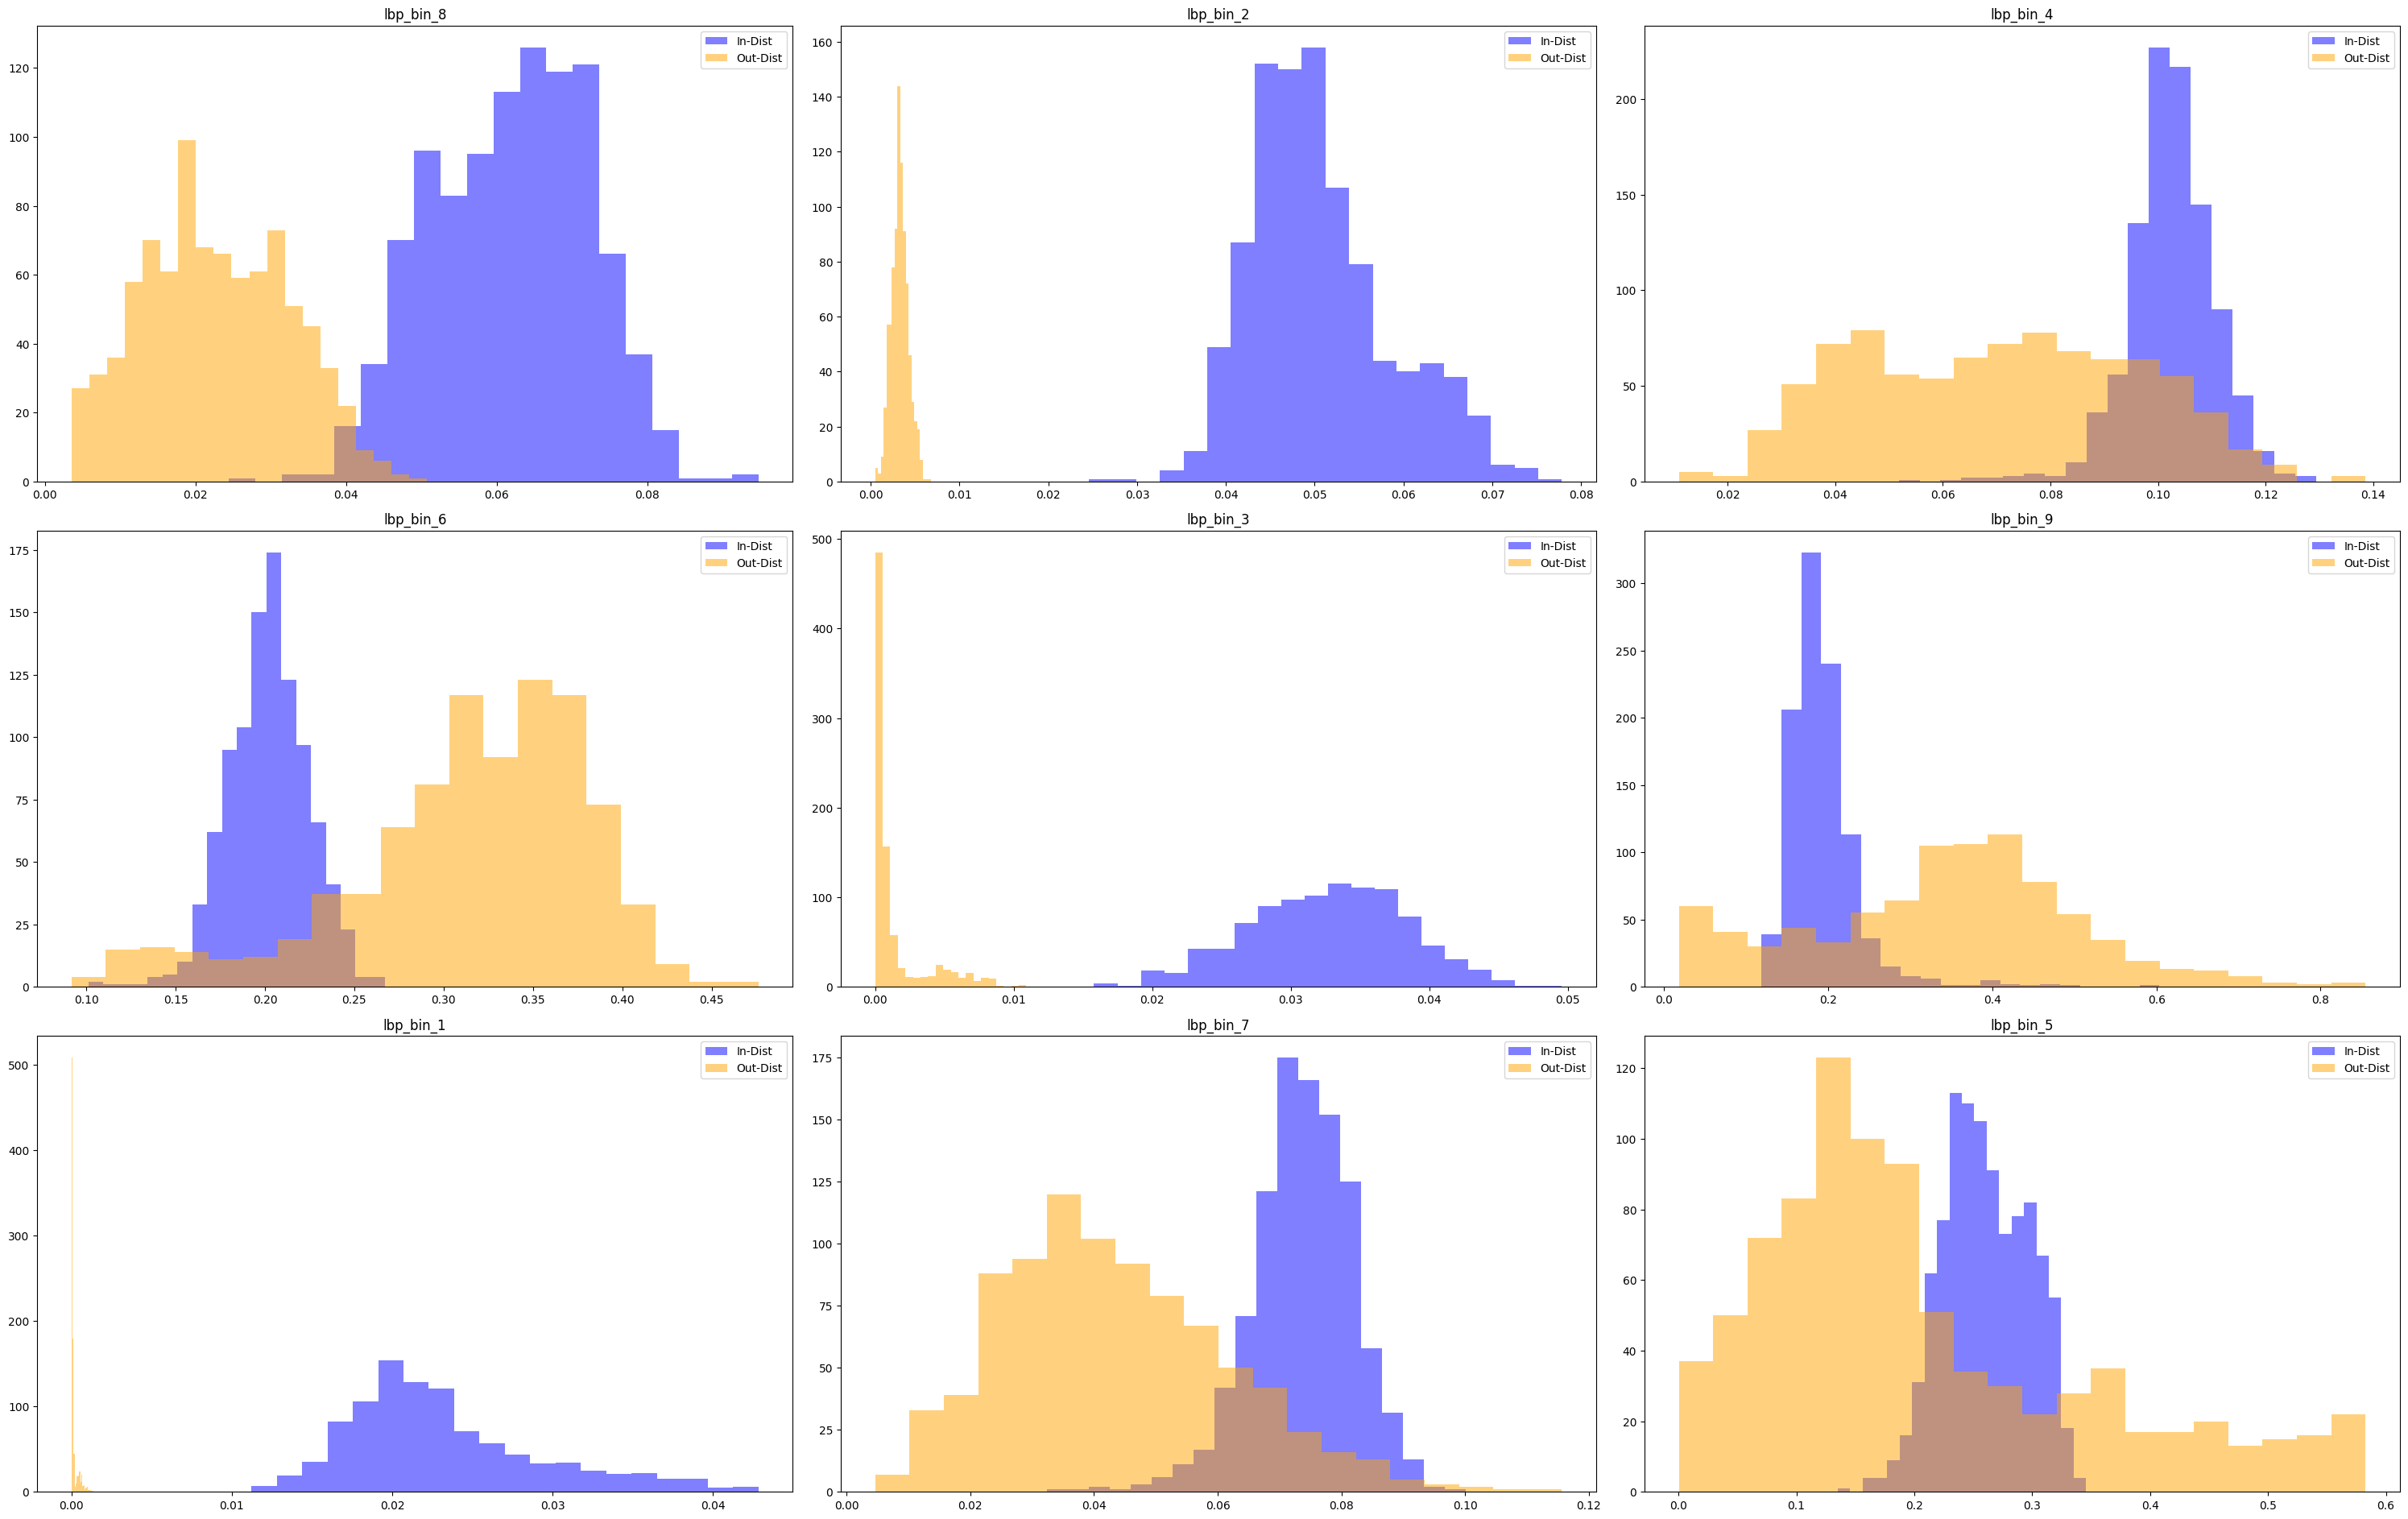

In [17]:
# --------- Visualization Functions --------- #

def plot_feature_distributions(in_features, out_features):
    """
    Plot histograms of feature distributions for in-distribution and out-distribution datasets.

    Parameters:
        in_features (DataFrame): Numeric features from the in-distribution dataset.
        out_features (DataFrame): Numeric features from the out-distribution dataset.
    """
    plt.figure(figsize=(30, 25))
    for i, column in enumerate(in_features.columns):
        plt.subplot(len(in_features.columns) // 3 + 1, 3, i + 1)
        plt.hist(in_features[column], bins=20, alpha=0.5, label="In-Dist", color="blue")
        plt.hist(out_features[column], bins=20, alpha=0.5, label="Out-Dist", color="orange")
        plt.title(column)
        plt.legend()
    plt.tight_layout()
    plt.show()


# Visualize feature distributions
print("Visualizing Feature Distributions...")
plot_feature_distributions(in_dist_values, out_dist_values)



Visualizing Features using t-SNE...


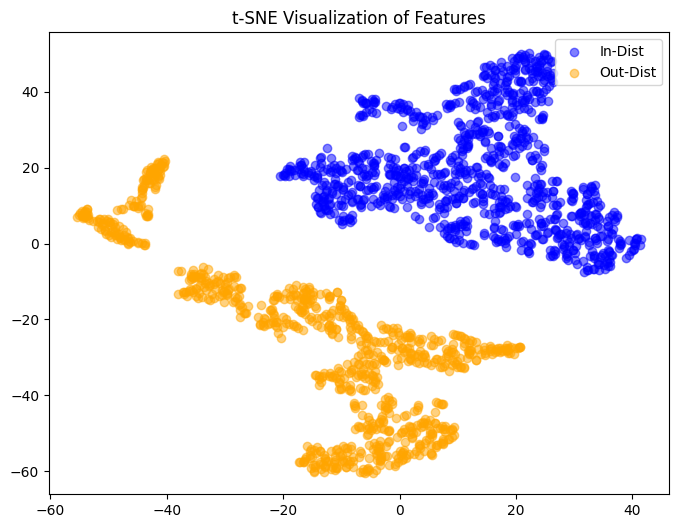

In [18]:
# --------- Visualization Functions --------- #

def plot_tsne(features, labels):
    """
    Visualize the features using t-SNE (t-Distributed Stochastic Neighbor Embedding).

    Parameters:
        features (array-like): Standardized feature values.
        labels (array-like): Corresponding labels (0: in-distribution, 1: out-distribution).
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for t-SNE visualization. Skipping...")
        return

    tsne = TSNE(n_components=2, random_state=42, init="random")
    reduced_features = tsne.fit_transform(features)
    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1], alpha=0.5, label=label_name, c=color)
    plt.title("t-SNE Visualization of Features")
    plt.legend()
    plt.show()

# Visualize features using t-SNE
print("Visualizing Features using t-SNE...")
plot_tsne(scaled_combined_values, labels)


Visualizing Features using PCA...


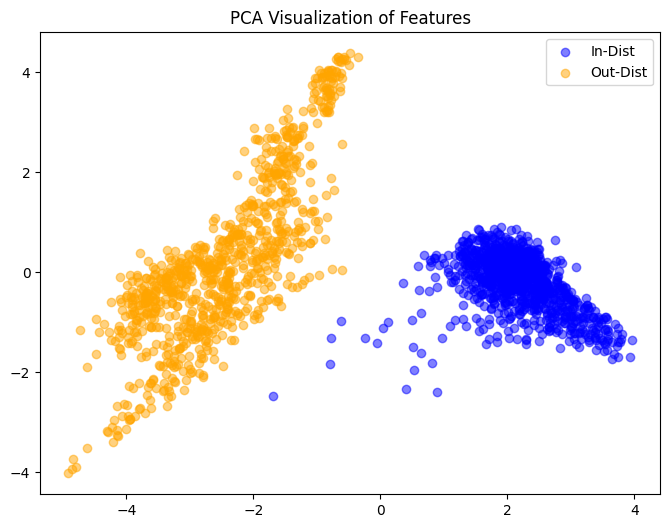

In [19]:
# --------- Visualization Functions --------- #

def plot_pca(features, labels):
    """
    Visualize the features using PCA (Principal Component Analysis).

    Parameters:
        features (array-like): Standardized feature values.
        labels (array-like): Corresponding labels (0: in-distribution, 1: out-distribution).
    """
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for PCA visualization. Skipping...")
        return

    pca = PCA(n_components=2)
    reduced_features = pca.fit_transform(features)
    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1], alpha=0.5, label=label_name, c=color)
    plt.title("PCA Visualization of Features")
    plt.legend()
    plt.show()


# Visualize features using PCA
print("Visualizing Features using PCA...")
plot_pca(scaled_combined_values, labels)


Visualizing KDE Distributions...


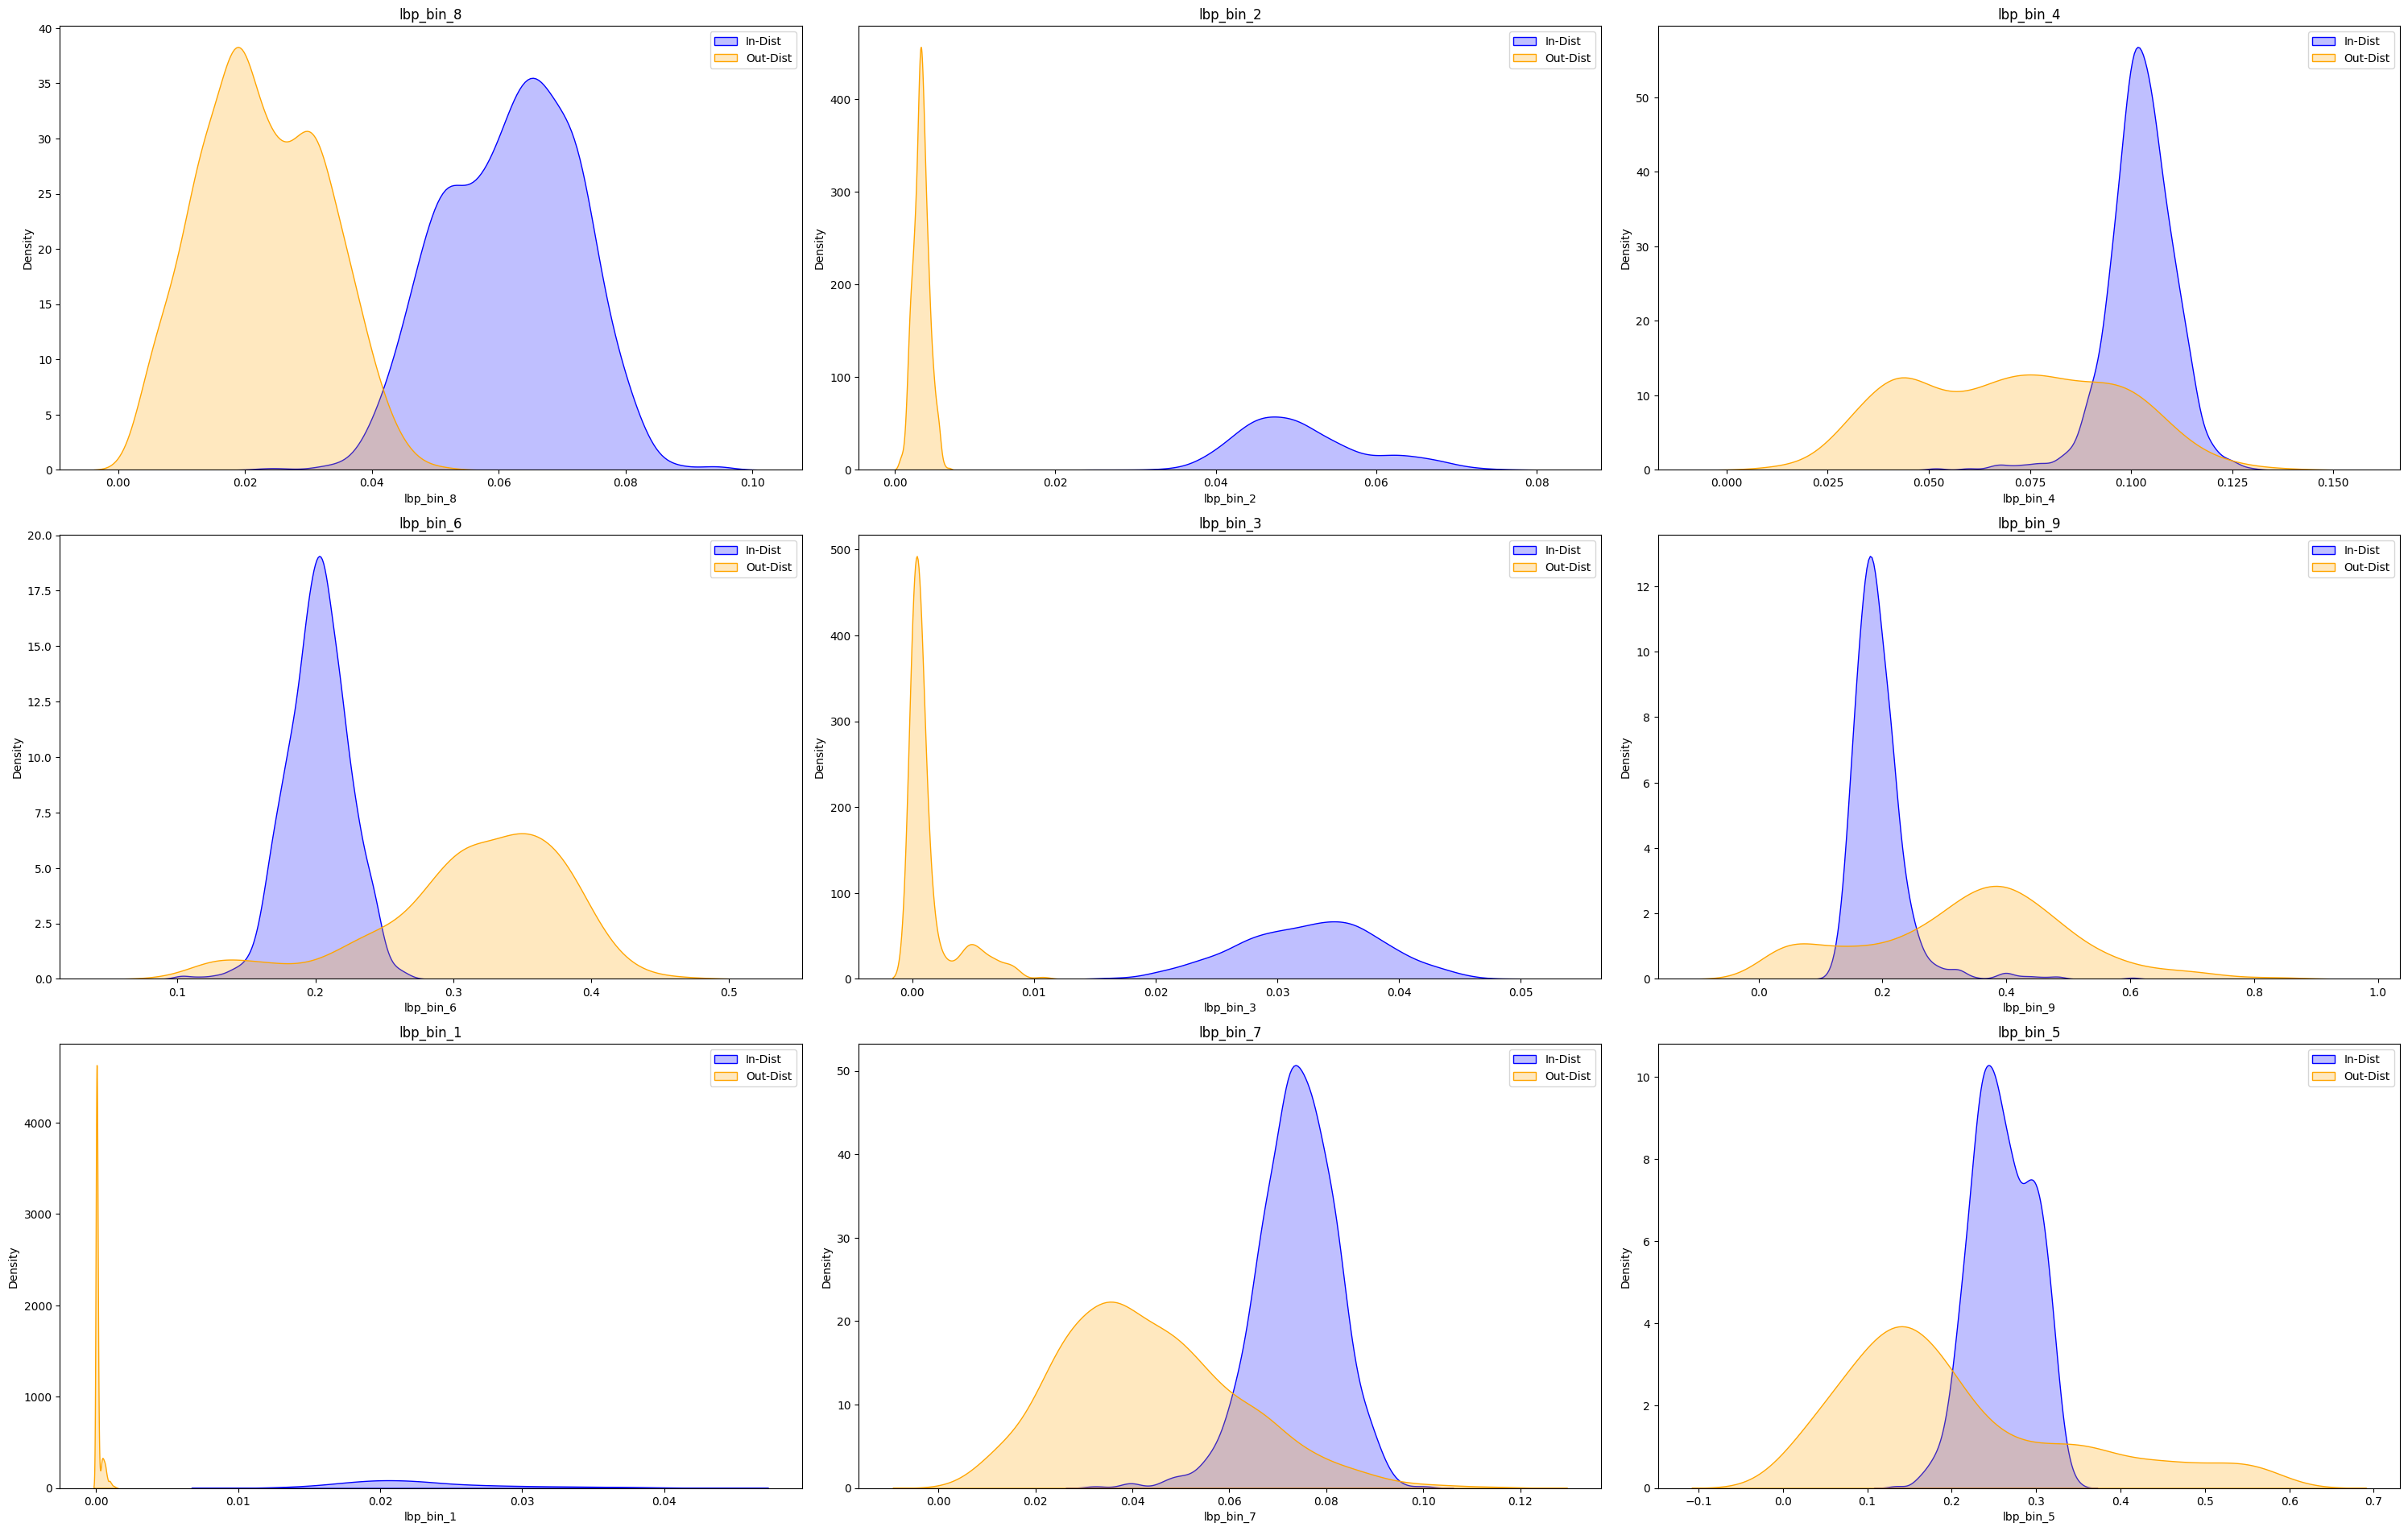

In [20]:
def plot_kde_distributions(in_features, out_features):
    """
    Plot KDE (Kernel Density Estimation) distributions for feature comparison.

    This function visualizes the distribution of each feature in the in-distribution
    and out-distribution datasets using KDE plots.

    Parameters:
        in_features (DataFrame): Numeric features from the in-distribution dataset.
        out_features (DataFrame): Numeric features from the out-distribution dataset.

    Behavior:
        - Each feature is plotted in a separate subplot.
        - KDE plots are overlaid to compare distributions between the two datasets.
        - The plot includes legends and is adjusted for a clean layout.
    """
    plt.figure(figsize=(30, 25))  # Set the figure size for multiple subplots
    for i, column in enumerate(in_features.columns):
        # Create subplots for each feature
        plt.subplot(len(in_features.columns) // 3 + 1, 3, i + 1)

        # KDE plot for in-distribution features
        sns.kdeplot(in_features[column], label="In-Dist", color="blue", fill=True)

        # KDE plot for out-distribution features
        sns.kdeplot(out_features[column], label="Out-Dist", color="orange", fill=True)

        # Add title and legend for each subplot
        plt.title(column)
        plt.legend()

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

# --------- Visualization Call --------- #

print("Visualizing KDE Distributions...")
plot_kde_distributions(in_dist_values, out_dist_values)


Visualizing Features using UMAP...


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


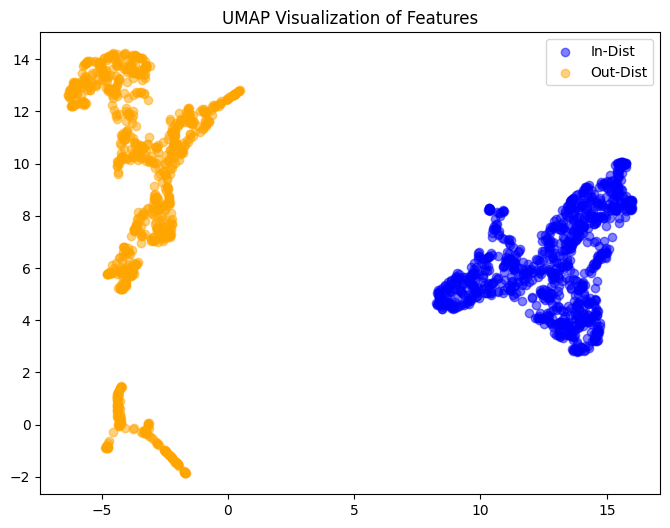

In [21]:
def plot_umap(features, labels):
    """
    Visualize features using UMAP (Uniform Manifold Approximation and Projection).

    UMAP is a dimensionality reduction technique that projects high-dimensional data
    into a 2D space while preserving its global structure, enabling effective visualization.

    Parameters:
        features (array-like): Standardized feature values.
        labels (array-like): Corresponding labels (0: in-distribution, 1: out-distribution).

    Behavior:
        - Projects the features into a 2D space using UMAP.
        - Creates a scatter plot to compare in-distribution and out-distribution data points.
        - Colors and labels the points based on their distribution type.

    Edge Cases:
        - If there are fewer than 2 features or samples, the function skips visualization.
    """
    # Check if there are enough features and samples for UMAP
    if features.shape[1] < 2 or features.shape[0] < 2:
        print("Insufficient features or samples for UMAP visualization. Skipping...")
        return

    # Initialize and fit UMAP
    umap = UMAP(n_components=2, random_state=42)
    reduced_features = umap.fit_transform(features)

    # Plot the reduced features
    plt.figure(figsize=(8, 6))
    for label, color, label_name in zip([0, 1], ["blue", "orange"], ["In-Dist", "Out-Dist"]):
        idx = labels == label
        plt.scatter(
            reduced_features[idx, 0],
            reduced_features[idx, 1],
            alpha=0.5,
            label=label_name,
            c=color
        )

    # Add title and legend to the plot
    plt.title("UMAP Visualization of Features")
    plt.legend()
    plt.show()

# --------- Visualization Call --------- #

print("Visualizing Features using UMAP...")
plot_umap(scaled_combined_values, labels)


Visualizing Pairwise Scatterplots...


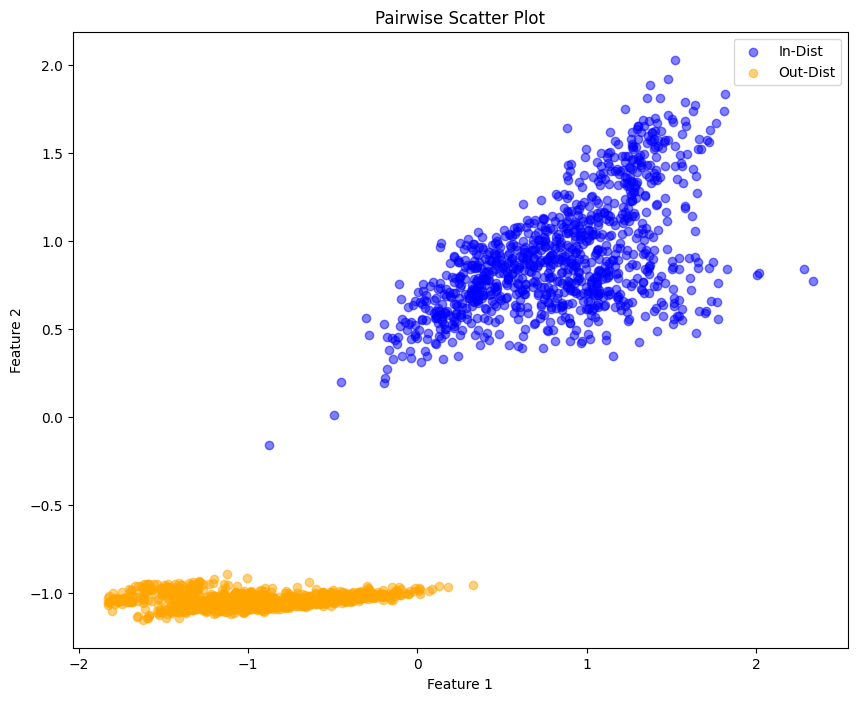

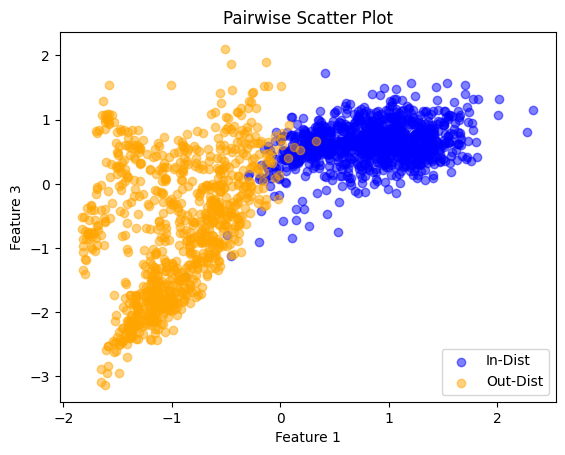

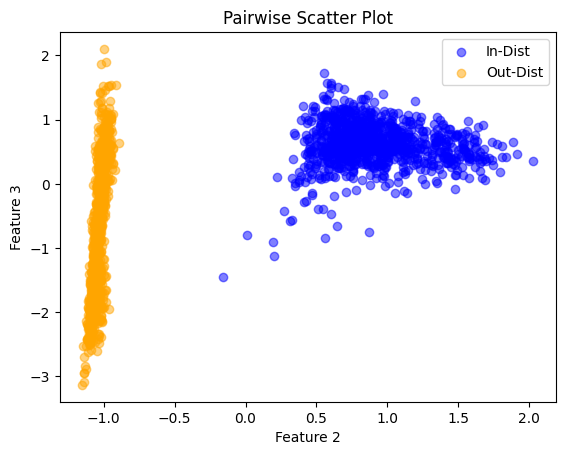

In [22]:
def plot_pairwise_scatter(features, labels):
    """
    Visualize pairwise scatter plots of selected features.

    This function generates scatter plots for the first three features in the dataset,
    showing their pairwise relationships. Points are color-coded based on their
    in-distribution (label 0) or out-distribution (label 1) classification.

    Parameters:
        features (array-like): Standardized feature values (2D array).
        labels (array-like): Corresponding labels (0: in-distribution, 1: out-distribution).

    Behavior:
        - Selects the first three features for visualization.
        - Creates pairwise scatter plots for all combinations of the three features.
        - Points are color-coded with transparency for better visualization.
        - Labels and legends are added for clarity.

    Notes:
        - Only the first three features are plotted for simplicity.
        - Ensures clear visual separation of in-distribution and out-distribution points.
    """
    sample_features = features[:, :3]  # Select the first 3 features for visualization
    plt.figure(figsize=(10, 8))  # Set figure size

    # Generate pairwise scatter plots
    for i in range(sample_features.shape[1] - 1):
        for j in range(i + 1, sample_features.shape[1]):
            # Scatter plot for in-distribution points
            plt.scatter(
                sample_features[labels == 0, i],
                sample_features[labels == 0, j],
                label="In-Dist",
                alpha=0.5,
                color="blue",
            )
            # Scatter plot for out-distribution points
            plt.scatter(
                sample_features[labels == 1, i],
                sample_features[labels == 1, j],
                label="Out-Dist",
                alpha=0.5,
                color="orange",
            )

            # Add axis labels and title
            plt.xlabel(f"Feature {i + 1}")
            plt.ylabel(f"Feature {j + 1}")
            plt.title("Pairwise Scatter Plot")
            plt.legend()

            # Show the plot
            plt.show()

# --------- Visualization Call --------- #

print("Visualizing Pairwise Scatterplots...")
plot_pairwise_scatter(scaled_combined_values, labels)


Visualizing Boxplots...


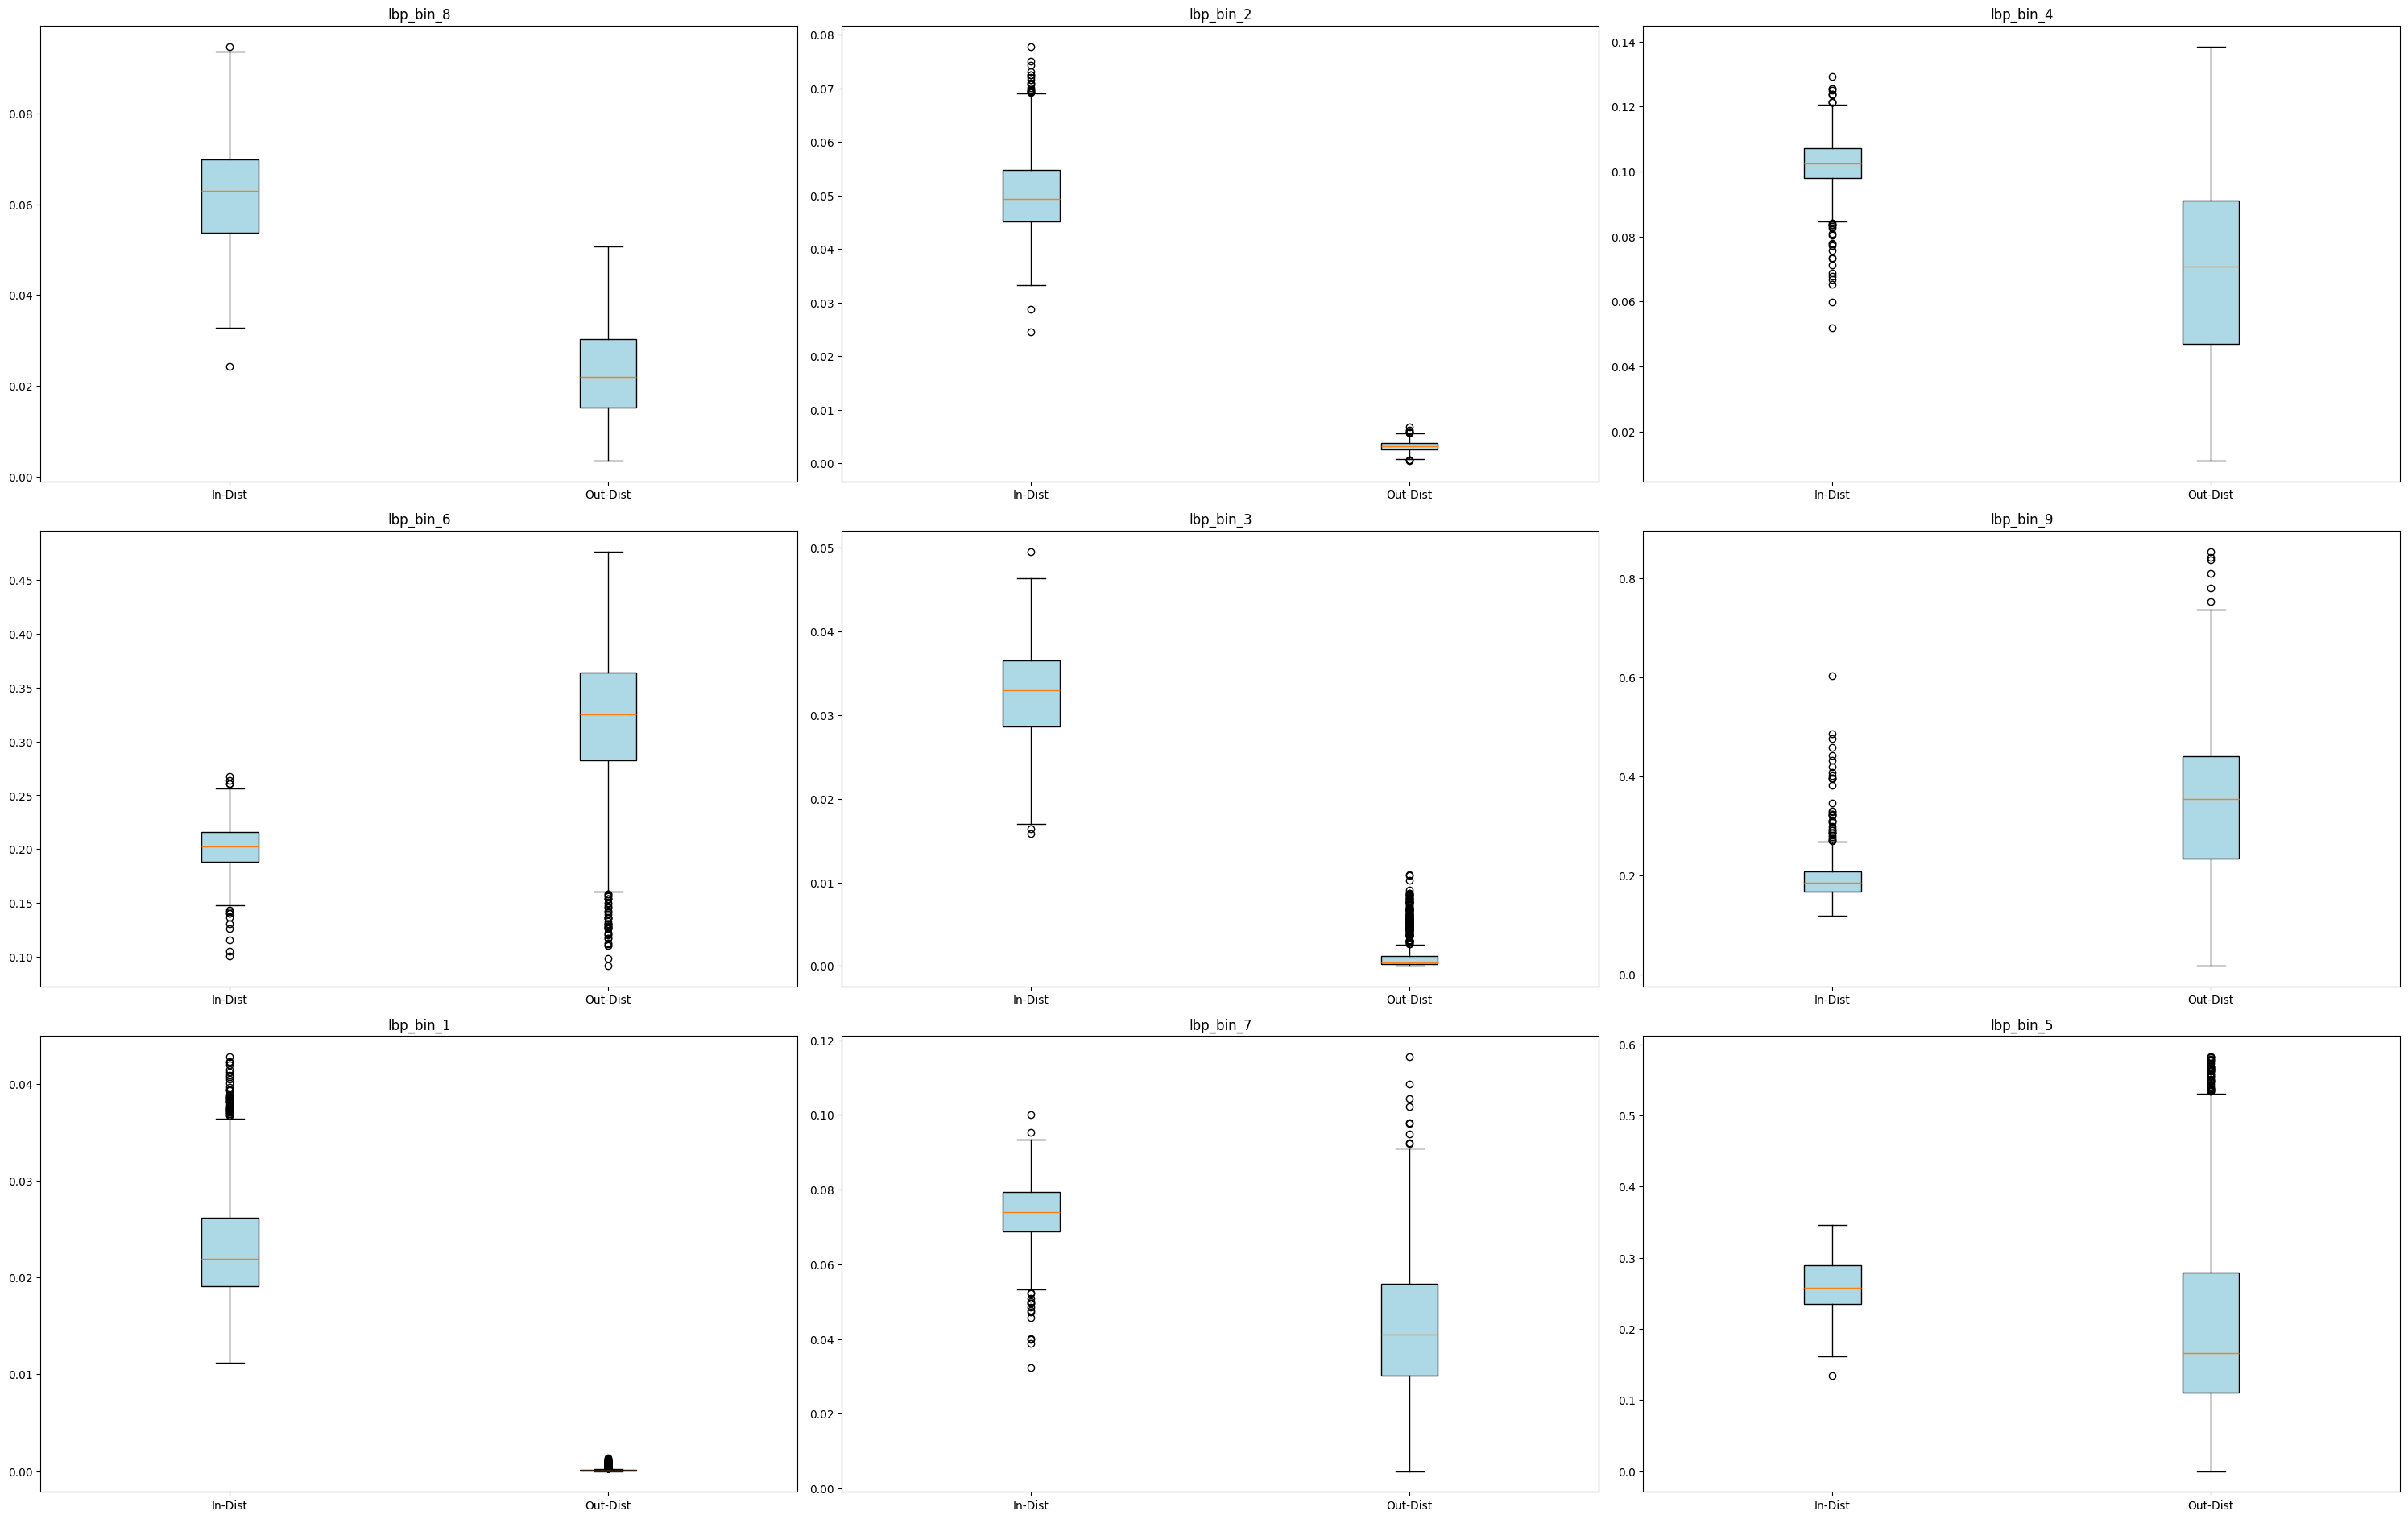

In [23]:
def plot_boxplots(in_features, out_features):
    """
    Visualize feature distributions using boxplots.

    This function generates boxplots for each feature in the dataset, comparing
    the in-distribution and out-distribution data. Boxplots summarize data distribution
    through quartiles and highlight outliers.

    Parameters:
        in_features (DataFrame): Numeric features from the in-distribution dataset.
        out_features (DataFrame): Numeric features from the out-distribution dataset.

    Behavior:
        - Creates a boxplot for each feature, comparing in-distribution and out-distribution values.
        - Uses labeled axes and visually distinct color coding for clarity.
        - Ensures compact and readable layout by dynamically arranging subplots.

    Why Boxplots are a Good Visualization Method:
        - Boxplots provide a concise summary of the data distribution, including:
            - Median (central tendency).
            - Interquartile range (IQR) showing spread.
            - Outliers, which might indicate significant deviations in the data.
        - This method is particularly effective for comparing distributions between two datasets (e.g., in-dist vs. out-dist).
        - It highlights differences in variability, centrality, and extreme values across features.
    """
    plt.figure(figsize=(30, 25))  # Set figure size for multiple subplots

    # Create a boxplot for each feature
    for i, column in enumerate(in_features.columns):
        plt.subplot(len(in_features.columns) // 3 + 1, 3, i + 1)

        # Generate boxplot comparing in-distribution and out-distribution data
        plt.boxplot(
            [in_features[column], out_features[column]],  # Data for boxplots
            labels=["In-Dist", "Out-Dist"],  # Labels for each group
            patch_artist=True,  # Enable color filling for boxes
            boxprops=dict(facecolor="lightblue"),  # Style for box fill
        )
        plt.title(column)  # Set the title to the feature name

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

# --------- Visualization Call --------- #

print("Visualizing Boxplots...")
plot_boxplots(in_dist_values, out_dist_values)
